## Lab6-Assignment: Topic Classification

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice.
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

In [2]:
!pip install transformers==4.57.6
!pip install simpletransformers==0.70.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 17.3 MB/s eta 0:00:00MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 18.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached grpcio-1.80.0-cp312-cp312-macosx_11_0_universal2.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 24.6 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 25.7 MB/s eta 0:00:0031m27.7 MB/s eta 0:00:01
Using cached grpcio-1.80.0-cp312-cp312-macosx_11_0_universal2.whl (12.0 MB)
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16161 sha256=33d16d30324a18eb739

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
import seaborn as sn

In [4]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

# remove the headers, footers and quotes (to avoid overfitting)
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

In [5]:
from collections import Counter
Counter(newsgroups_train.target)

Counter({2: 594, 3: 593, 1: 584, 0: 480})

In [6]:
Counter(newsgroups_test.target)

Counter({2: 396, 3: 394, 1: 389, 0: 319})

In [7]:
train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})

In [8]:
print(len(train))
train.head(5)

2251


,text,labels
0,WHile we are on the subject of the shuttle sof...,3
1,There is a program called Graphic Workshop you...,1
2,,2
3,My girlfriend is in pain from kidney stones. S...,2
4,I think that's the correct spelling..\n\tI am ...,2


In [9]:
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})

In [10]:
print(len(test))
test.head(5)

1498


,text,labels
0,\nAnd guess who's here in your place.\n\nPleas...,1
1,Does anyone know if any of Currier and Ives et...,1
2,=FLAME ON\n=\n=Reading through the posts about...,2
3,\nBut in this case I said I hoped that BCCI wa...,0
4,\nIn the kind I have made I used a Lite sour c...,2


In [11]:
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0,
                               stratify=train[['labels']])

In [12]:
print(len(train))
print("train:", train[['labels']].value_counts(sort=False))
train.head(3)

2025
train: labels
0         432
1         525
2         534
3         534
Name: count, dtype: int64


,text,labels
559,I wonder how many atheists out there care to s...,0
2060,We are interested in purchasing a grayscale pr...,1
1206,"Dear Binary Newsers,\n\nI am looking for Quick...",1


In [13]:
print(len(dev))
print("dev:", dev[['labels']].value_counts(sort=False))
dev.head(3)

226
dev: labels
0         48
1         59
2         60
3         59
Name: count, dtype: int64


,text,labels
1570,I'd dump him. Rude is rude and it seems he en...,2
1761,Hi Everyone ::\n\nI am looking for some soft...,1
455,A friend of mine has been diagnosed with Psori...,2


In [14]:
# Model configuration # https://simpletransformers.ai/docs/usage/#configuring-a-simple-transformers-model
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model
# (eval data should be passed to the training method)

model_args.num_train_epochs=10 # number of epochs
model_args.train_batch_size=32 # batch size
model_args.learning_rate=4e-6 # learning rate
model_args.max_seq_length=256 # maximum sequence length
# Note! Increasing max_seq_len may provide better performance, but training time will increase.
# For educational purposes, we set max_seq_len to 256.

# Early stopping to combat overfitting: https://simpletransformers.ai/docs/tips-and-tricks/#using-early-stopping
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 # "The improvement over best_eval_loss necessary to count as a better checkpoint"
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32 # how often you want to run validation in terms of training steps (or batches)

In [15]:
# Checking steps per epoch
steps_per_epoch = int(np.ceil(len(train) / float(model_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch)) # 64 steps = validating 2 times per epoch

Each epoch will have 64 steps.


In [ ]:
model = ClassificationModel('roberta', 'roberta-base', num_labels=4, args=model_args, use_cuda=True)

In [16]:
_, history = model.train_model(train, eval_df=dev)

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Running Epoch 1 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


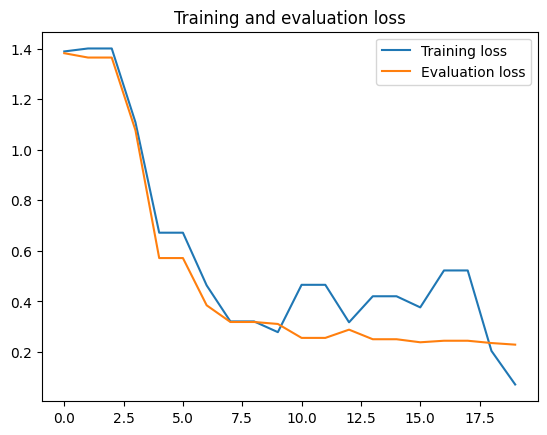

In [17]:
# Training and evaluation loss
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [18]:
# Evaluate the model
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

0it [00:00, ?it/s]

Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


{'mcc': np.float64(0.8467073706955812), 'eval_loss': 0.2293047954638799}

In [ ]:
predicted, probabilities = model.predict(test.text.to_list())
test['predicted'] = predicted

In [20]:
test.head(5)

,text,labels,predicted
0,\nAnd guess who's here in your place.\n\nPleas...,1,3
1,Does anyone know if any of Currier and Ives et...,1,1
2,=FLAME ON\n=\n=Reading through the posts about...,2,0
3,\nBut in this case I said I hoped that BCCI wa...,0,0
4,\nIn the kind I have made I used a Lite sour c...,2,2


In [21]:
# Result (note: your result can be different due to randomness in operations)
print(classification_report(test['labels'], test['predicted']))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82       319
           1       0.90      0.89      0.89       389
           2       0.86      0.91      0.88       396
           3       0.86      0.81      0.83       394

    accuracy                           0.86      1498
   macro avg       0.86      0.86      0.86      1498
weighted avg       0.86      0.86      0.86      1498



In [17]:
print(test.columns)

Index(['text', 'labels'], dtype='object')


# Conventional machine learning baseline: TF-IDF + SVM

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

svm_clf = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000)),
    ('clf', LinearSVC())
])

svm_clf.fit(train['text'], train['labels'])

svm_predicted = svm_clf.predict(test['text'])

print(classification_report(
    test['labels'],
    svm_predicted,
    target_names=newsgroups_train.target_names
))

               precision    recall  f1-score   support

  alt.atheism       0.84      0.76      0.80       319
comp.graphics       0.88      0.89      0.88       389
      sci.med       0.88      0.83      0.85       396
    sci.space       0.78      0.86      0.82       394

     accuracy                           0.84      1498
    macro avg       0.84      0.84      0.84      1498
 weighted avg       0.84      0.84      0.84      1498



* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice.
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

## Comparison of RoBERTa, BERT, and SVM

RoBERTa model achieved an accuracy of 0.86, with both macro and weighted F1-scores equal to 0.86. Its best results were on `comp.graphics` and `sci.med`, with F1-scores of 0.89 and 0.88. 

BERT model from Lab6.4 performed slightly better overall, with an accuracy and macro F1-score of 0.87. It achieved the highest F1-score on `comp.graphics` (0.91) and also performed very well on `sci.med` (0.90). 
RoBERTa and BERT result difference is relatively small, so both transformer-based models are effective for text classification. 

SVM classifier achieved an accuracy and macro F1-score of 0.84. This is slightly lower than both transformer models. SVM still performed well on categories with distinctive vocabulary, such as `comp.graphics`, but overall it had lower recall and F1-scores.
For example, SVM `alt.atheism` recall was 0.76 compared to 0.82 for both RoBERTa and BERT. Transformer-based models have an advantage because they use contextual embeddings, while SVM mainly relies on word-frequency information from TF-IDF features.